# Firm characteristics: changing the objective without changing the target

[`05_linear`](05_linear.ipynb) ended on a diagnosis rather than a result. Fitting the whole
cross-section of firm characteristics at once produced nothing on `fwd_ret_1m`, and the
explanation it offered was not about the features - `04_evaluation` had already shown those
order the cross-section one at a time - but about the target. A monthly cross-section of
individual US stocks is extremely heavy-tailed: most firms move a few percent and a few of them
multiply. A linear model fits by **minimizing squared error**, so a firm that returned several
multiples of its price contributes in proportion to the square of that return, while the
**information coefficient** is a rank correlation that counts it as one observation among
thousands. The fit is steered by exactly the observations the metric is indifferent to.

That notebook tested the diagnosis by changing the target - refitting the same grid on the
winsorized variant `fwd_ret_1m_win`. This one tests it a second way, and the second way is
cleaner: **the target is held fixed and the objective is varied instead.** The declared grid
fits every capacity setting under three loss functions on the identical label, identical
features and identical folds:

- **`mse`** minimizes squared error, and is what the linear models minimized.
- **`mae`** minimizes absolute error, so an observation contributes in proportion to how wrong
  it is rather than to its square.
- **`huber`** behaves like squared error for small residuals and like absolute error past a
  threshold derived from each fold's own label spread, so it is quadratic where the data is
  well behaved and linear where it is not.

If the diagnosis in `05_linear` is right, the three objectives should separate on this label,
in that order, and by more than they would on a case study whose returns are better behaved.
Nothing about the features or the sample changes between them.

Two other dials are in the grid, and they are not the point but they are not free either:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into.
  Trees also bring what the linear models could not represent at all - an interaction is
  something a tree discovers by splitting on one characteristic inside a region defined by
  others, rather than something someone had to multiply together and name.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so each configuration is scored at ten points along its own training run.

That last one changes how the results must be read. **A checkpoint is part of a configuration,
not a detail of how it was fitted.** Scoring 15 declared configurations at ten checkpoints each
produces 150 candidate models, and treating that as 15 candidates while quietly keeping each
one's best iteration would be reporting the maximum of ten numbers as though it were one.

**Learning objectives.** By the end of this notebook you will be able to:

- Say why a squared-error fit and a rank correlation can disagree about the same model, and
  design a comparison that isolates the objective from the target.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and tell
  apart a model still learning from one that has begun fitting the training window.
- Recognise that picking each configuration's best checkpoint after seeing the results is a
  selection decision, and locate where selection is actually made.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) has written the
characteristic matrix, [`04_evaluation`](04_evaluation.ipynb) has screened the characteristics
individually and established the walk-forward folds, and [`05_linear`](05_linear.ipynb) fitted
the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`11_backtest`](11_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared firm-characteristics gradient boosting population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABEL = "fwd_ret_1m"
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = "us_firm_characteristics-gbm-validation-v1"

In [3]:
study = open_study(
    "us_firm_characteristics", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which label, and which models

The label is the one the linear notebook used: `fwd_ret_1m`, the total return over the month
after the decision date, unwinsorized. Holding it fixed is the whole design of this notebook -
the objectives differ, the target does not. The case study also declares `fwd_ret_1m_win`, the
winsorized variant `05_linear` used to make the same point by changing the target instead, and
`fwd_class_1m`, which turns the return into a class. `LABEL` above selects among them, and each
carries its own training menu at `config/training/{label}.yaml`.

In [4]:
declared_labels(study, "gbm")

('fwd_class_1m', 'fwd_ret_1m', 'fwd_ret_1m_win')

The menu lists 15 named configurations under `gbm:`, and each resolves to a preset in
`case_studies/config/lgb/`. The grid is a product of two axes: five capacity profiles -
`default` uses the library's own leaf count and the rest fix it at 7, 15, 31 and 63 - crossed
with the three objectives described above. Every configuration runs the same number of boosting
iterations at the same learning rate, so the grid isolates capacity and loss rather than
confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=[LABEL],
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_ret_1m""","""default_mse""","""""","""objective=regression, seed=42"""
"""gbm""","""fwd_ret_1m""","""default_mae""","""""","""objective=regression_l1, seed=…"
"""gbm""","""fwd_ret_1m""","""default_huber""","""""","""objective=huber, seed=42"""
"""gbm""","""fwd_ret_1m""","""leaves_7_mse""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1m""","""leaves_7_mae""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_1m""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1m""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_1m""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those, and on this label it is the interesting one: it is a fraction
of the training labels' standard deviation, so it is a different number on every fold and is
resolved from that fold's own data rather than fixed in advance.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row
  that differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [6]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,date,date
"""default_huber""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""default_mae""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""default_mse""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_15_huber""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_15_mae""",57,3708,252008,10,10,2006-11-30,2015-12-31
…,…,…,…,…,…,…,…
"""leaves_63_mae""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_63_mse""",57,3708,252008,10,10,2006-11-30,2015-12-31
"""leaves_7_huber""",57,3708,252008,10,10,2006-11-30,2015-12-31


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made, which matters on characteristics that are simply
   not reported for some firms in some months,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparation happens once per fold and is shared by every configuration, because slicing the
window and cleaning the rows depends on the data and not on the model. The run walks folds on
the outside and configurations on the inside for the same reason: one prepared fold is held at a
time rather than the whole set, which is what keeps a panel this size inside memory.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [7]:
execution, population = run_model_population(study, resolved, population_name=POPULATION_NAME)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

15 configurations fitted
population us_firm_characteristics-gbm-validation-v1: 150 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("us_firm_characteristics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_1m"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: in each
validation month, rank the firms by the model's prediction, rank them by the return they went on
to earn, correlate the two rankings, and average that monthly correlation over the validation
period.

The table is sorted by IC, and the top of it is the trap this notebook exists to describe. The
leading row is the maximum of 150 numbers. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

`ic_n_days` carries the second warning: a configuration that scored fewer months than its
neighbours is not comparable to them, because its IC is an average over the months where it
stayed non-degenerate. Every comparison below is restricted to full-coverage members.

In [8]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("ic_mean", descending=True)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

full_days = int(catalog.get_column("ic_n_days").max())
catalog = catalog.with_columns(full_coverage=pl.col("ic_n_days") == full_days)

print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each")
catalog.select(
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

150 candidate models: 15 configurations
at 10 checkpoints each


config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,i64,f64,f64,f64,bool
"""leaves_63_mae""",50,0.083444,0.035959,110.0,true
"""leaves_15_mae""",50,0.082414,0.038746,110.0,true
"""leaves_31_mae""",50,0.08238,0.037811,110.0,true
"""leaves_31_mae""",150,0.082375,0.035524,110.0,true
"""leaves_31_mae""",100,0.08222,0.036528,110.0,true
…,…,…,…,…,…
"""leaves_31_huber""",150,0.082079,0.033249,110.0,true
"""leaves_31_huber""",100,0.082044,0.033512,110.0,true
"""leaves_31_mae""",200,0.081915,0.034895,110.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

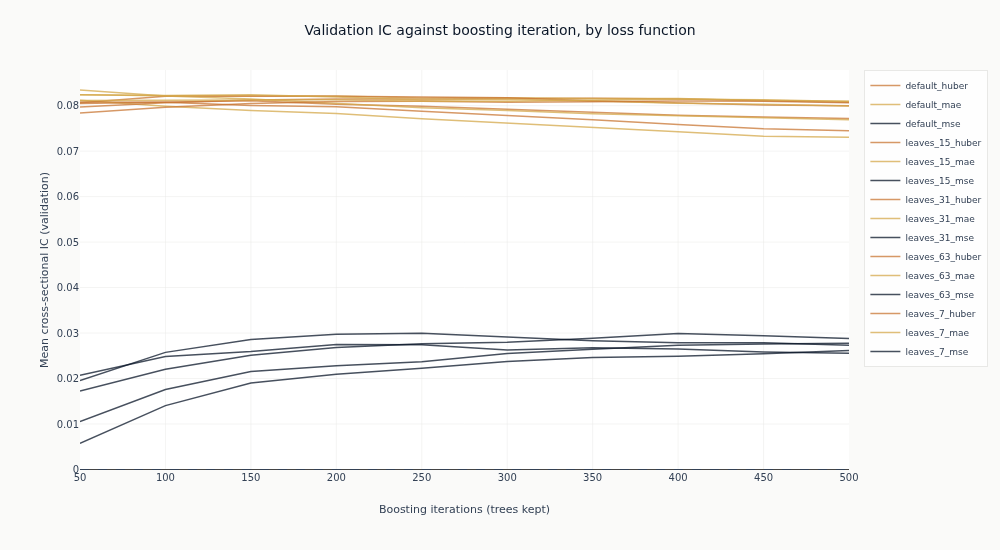

In [9]:
curves = catalog.filter("full_coverage").sort("config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    return next((key for key in objectives if name.endswith(key)), "mse")


fig_curves = go.Figure()
for config_name in curves.get_column("config_name").unique(maintain_order=True):
    series = curves.filter(pl.col("config_name") == config_name)
    fig_curves.add_trace(
        go.Scatter(
            x=series.get_column("checkpoint_value").to_list(),
            y=series.get_column("ic_mean").to_list(),
            mode="lines",
            name=config_name,
            line=dict(color=objectives[objective_of(config_name)], width=1.5),
            opacity=0.75,
        )
    )
fig_curves.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function",
    height=550,
    width=1000,
    margin=dict(t=70),
    legend=dict(font=dict(size=9)),
)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)")
fig_curves.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_curves,
    "Line chart of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: blue for squared error, amber for absolute "
    "error, copper for Huber. A dashed line marks zero. The chart divides into two bands that "
    "never meet. The amber and copper lines enter at the first checkpoint already at the top of "
    "the chart and run almost flat across the whole range. The blue lines enter near the zero "
    "line, climb steadily throughout, and are still rising at the last checkpoint, ending far "
    "below the amber and copper band.",
)

### Whether the loss function is what separates them

This is the figure the notebook was built for. The curves are coloured by objective because that
is the axis with a mechanism behind it, and on this label the mechanism is the strongest claim
`05_linear` made. If heavy tails are steering the squared-error fits, the three colours should
separate, and they should separate more as trees are added, since each additional tree is fitted
to the residuals the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

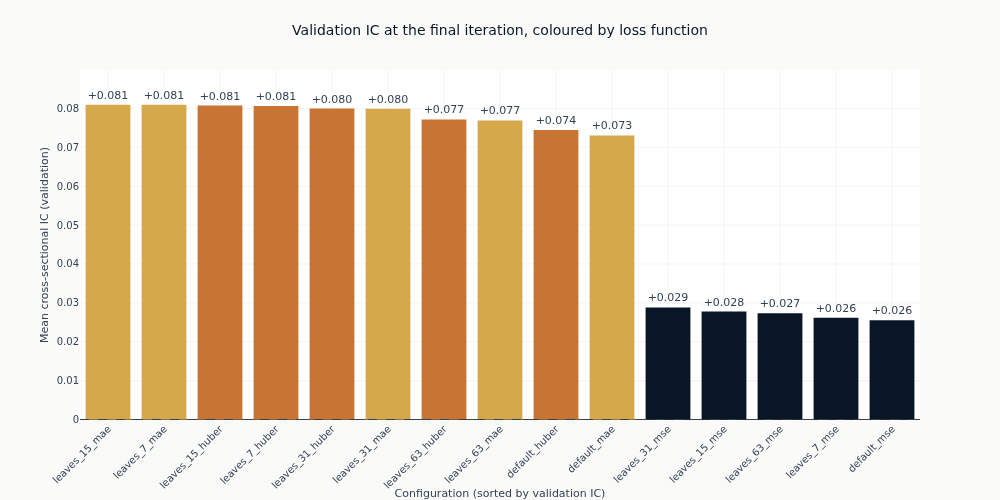

In [10]:
final_iteration = int(catalog.get_column("checkpoint_value").max())
final = (
    catalog.filter(pl.col("checkpoint_value") == final_iteration)
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort("ic_mean", descending=True)
)

fig_obj = go.Figure(
    go.Bar(
        x=final.get_column("config_name").to_list(),
        y=final.get_column("ic_mean").to_list(),
        marker_color=[objectives[value] for value in final.get_column("objective")],
        text=[f"{value:+.3f}" for value in final.get_column("ic_mean")],
        textposition="outside",
        cliponaxis=False,
    )
)
fig_obj.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig_obj.update_layout(
    title="Validation IC at the final iteration, coloured by loss function",
    height=500,
    width=1000,
    showlegend=False,
    margin=dict(t=70),
)
fig_obj.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_obj.update_yaxes(title_text="Mean cross-sectional IC (validation)")
show_plotly_with_alt(
    fig_obj,
    "Bar chart of mean validation information coefficient for every full-coverage configuration "
    "at its final boosting iteration, sorted descending and coloured by loss function, against a "
    "dashed zero line. All fifteen bars are above the line and they form two clearly separated "
    "groups. The ten leftmost bars are amber absolute-error and copper Huber configurations "
    "interleaved with each other, all at nearly the same height. The five rightmost are blue "
    "squared-error configurations, also close to each other but at roughly a third the height, "
    "with a visible step down between the two groups.",
)

### The objectives, summarized

The bar chart shows fifteen configurations; the claim under test is about three groups. The
table below takes the middle of each objective's own five configurations, which is the
comparison `05_linear` predicted the sign and the order of before any of this was fitted.

In [11]:
by_objective = (
    final.group_by("objective")
    .agg(
        ic_median=pl.col("ic_mean").median(),
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        n_positive=(pl.col("ic_mean") > 0).sum(),
        n=pl.len(),
    )
    .sort("ic_median", descending=True)
)
by_objective

objective,ic_median,ic_min,ic_max,n_positive,n
str,f64,f64,f64,u32,u32
"""huber""",0.079981,0.074479,0.080752,5,5
"""mae""",0.079947,0.073068,0.080945,5,5
"""mse""",0.027336,0.025552,0.028814,5,5


### How much the checkpoint moves a configuration

One number per configuration: the range its IC covers across its own ten checkpoints. This is
the quantity that decides whether choosing a stopping point is a decision worth making carefully
or one being made by noise. A configuration whose IC varies more across its own training run
than the configurations vary among themselves is one where the checkpoint, not the model, is
doing the ranking.

In [12]:
spread = (
    curves.group_by("config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort("checkpoint_range", descending=True)
)
across_configs = float(final.get_column("ic_mean").max() - final.get_column("ic_mean").min())
print(f"IC range across configurations at the final iteration: {across_configs:.4f}")
print(
    f"median IC range within one configuration: {spread.get_column('checkpoint_range').median():.4f}"
)
spread

IC range across configurations at the final iteration: 0.0554
median IC range within one configuration: 0.0063


config_name,ic_min,ic_max,ic_final,checkpoint_range
str,f64,f64,f64,f64
"""leaves_7_mse""",0.005739,0.026144,0.026144,0.020406
"""leaves_15_mse""",0.010524,0.027758,0.027758,0.017234
"""leaves_31_mse""",0.017255,0.029896,0.028814,0.01264
"""leaves_63_mse""",0.019533,0.029958,0.027336,0.010424
"""default_mae""",0.073068,0.081168,0.073068,0.0081
…,…,…,…,…
"""leaves_31_mae""",0.079947,0.08238,0.079947,0.002433
"""leaves_31_huber""",0.079981,0.082092,0.079981,0.00211
"""leaves_15_huber""",0.079722,0.081617,0.080752,0.001895


## 5. What to notice

**The objective decides the result, and the separation is complete.** Every absolute-error and
every Huber configuration outranks every squared-error one, with no overlap between the groups
and a gap of roughly three times between them. Sorted by IC, the ten robust-loss configurations
occupy the first ten places and the five squared-error ones the last five. That is the
prediction [`05_linear`](05_linear.ipynb) made from the shape of this label before any of it was
fitted, and this is the controlled form of the test: the target, the characteristics, the folds
and the months scored are identical across all fifteen, and the outcome the IC is measured
against is the same continuous return in every case - only what the fit was asked to minimize
differs. The linear grid on this same label scored below zero throughout.

**What matters is robust or not, rather than which robust loss.** Absolute error and Huber are
indistinguishable here: they interleave through the top ten and the whole spread within that
group is small next to the distance to squared error. Huber exists to be quadratic where the
data is well behaved and linear where it is not, and on a label this heavy-tailed almost
everything of consequence lies in the region where it has already become absolute error. So the
decision worth making carefully is whether the extremes are allowed to steer the fit at all.

**The loss function is worth far more than the capacity.** Within either group, moving the leaf
count from 7 to 63 changes the IC by a small fraction of what changing the objective changes.
The dial the literature spends most of its tuning effort on is, on this data, an order of
magnitude less important than the one that is usually left at its default.

**The learning curves say why, and this is the mechanism made visible.** The robust-loss
configurations arrive at their final level by the first checkpoint and then stay flat for the
remaining nine - they have the ranking after fifty trees and further trees add nothing to it.
The squared-error configurations start near zero, climb steadily, and most of them are still
climbing at the end of training. Squared error weights an observation by the square of its
error, so its early trees are spent on the firms that multiplied, which is effort a rank
correlation is indifferent to; it accumulates ranking information slowly and as a by-product.
Absolute error weights an observation by how wrong it is, and gets the ranking immediately.

**Here the checkpoint is a small dial, which is not a general fact.** Across the fifteen
configurations at fixed training length the IC spans a wide range; within a single configuration,
across its own ten checkpoints, the median range is roughly a ninth of that. So on this case
study the stopping point barely moves the answer - because the objective gap dominates
everything else. That is the opposite of what the same grid shows on a case study whose
objectives do not separate, where the checkpoint and the model matter about equally. Neither is
the general case, which is the reason the checkpoint is registered as part of a configuration
rather than resolved away: how much it matters is a property of the data and has to be measured.

**None of this selects anything.** IC measures whether predictions rank firms correctly, not
whether a strategy trading them makes money after costs and turnover. A monthly cross-section of
individual stocks is also where the ranking advantage and the tradeable advantage diverge most,
because the firms whose returns are hardest to predict are disproportionately the small and
illiquid ones. Selection is on validation backtest Sharpe over the population just published,
and it happens in [`11_backtest`](11_backtest.ipynb), where the checkpoint is part of what is
selected.

**Known limitations.** The IC is an average of monthly rank correlations with no adjustment for
serial dependence, so it is a diagnostic rather than a test, and it carries no interval that
would say whether absolute error and Huber differ from each other - the reading above is that
they do not, and the evidence for that is the size of the within-group spread rather than a
test. The grid varies capacity and loss at a fixed learning rate and a fixed training length,
and the previous points are the reason the last of those matters: the squared-error
configurations have not converged at the training length declared here, so their numbers are a
lower bound on what that objective would eventually reach. And every number is measured on
validation folds that have been read many times over by the time a case study reaches this
notebook.

**Next**: [`07_tabular_dl`](07_tabular_dl.ipynb) asks the same question of a neural network built
for tabular data. It optimizes a loss function too, and the one it is given is a choice made the
same way this one was - so the thing to watch is whether the objective matters there for the
same reason it matters here.